<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/06_ML_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 6: Machine Learning Modelling — XGBoost & SHAP Interpretability
**Project:** Impact of Energy Efficiency on UK House Prices (2021–2025)

---

## Introduction and Methodological Strategy

This notebook concludes the comparative Machine Learning pipeline of Objective 1 by evaluating **eXtreme Gradient Boosting (XGBoost)** — widely recognized as the industry gold standard for structured tabular data. Subsequently, this model will serve as the mathematical engine for Objective 2: applying the **SHAP (SHapley Additive exPlanations)** framework to isolate the exact monetary value of the *Green Premium* with surgical precision.

**XGBoost Architecture & Computational Strategy:** Like LightGBM, XGBoost is a *Gradient Boosting* algorithm. Its distinguishing strengths are advanced L1/L2 regularization and second-order gradient approximation. Crucially, we will reactivate hardware acceleration (`device='cuda'`, `tree_method='hist'`) to process the hyperparameter optimization at maximum speed.

**Methodological Constants (The JSON Lock):**
To guarantee a perfectly fair comparison, we maintain strict data cleaning and immediately load the canonical 53-feature matrix (`approved_features_53.json`) post-split. This ensures XGBoost competes in the exact same spatial and structural arena as LightGBM and Random Forest.

In [ ]:
# ── CELL 0: Install External Dependencies ────────────────────────────────────
# Run once per Colab session.
!pip install optuna --quiet
!pip install shap   --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.2 MB/s eta 0:00:00


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 06 — XGBoost: Gradient Boosting Champion & SHAP Interpretability
# Project : Impact of Energy Efficiency on UK House Prices (2021–2025)
# Phase   : Machine Learning Modelling — XGBoost + SHAP
# ══════════════════════════════════════════════════════════════════════════════

# ── 0. Install External Dependencies ──────────────────────────────────────────
# Run once per Colab session.
!pip install optuna --quiet
!pip install shap   --quiet

# ── 1. Standard Library & Data Processing ─────────────────────────────────────
import os
import gc
import re
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── 2. Machine Learning ───────────────────────────────────────────────────────
import xgboost as xgb
import optuna
import joblib
import shap
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

# ── 3. Visualisation & Aesthetics Setup ───────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'axes.titlesize':        14,
    'axes.titlepad':         16,
    'axes.labelsize':        12,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':        9,
    'legend.title_fontsize': 11,
})
ACCENT = 'crimson'   # XGBoost visual identity

# ── 4. Mount Drive ────────────────────────────────────────────────────────────
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Pipeline & Canonical Parity Enforcement
Mirroring previous models, the dataset is loaded, cleaned, and heavily memory-optimized. The definitive methodological step occurs immediately after the 80/20 train-test split: filtering both matrices through the `approved_features_53.json` file.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Data Ingestion & Feature Space Parity
# ══════════════════════════════════════════════════════════════════════════════

DATA_PATH   = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
MODELS_PATH = '/content/drive/MyDrive/Tese/Modelos/'
os.makedirs(MODELS_PATH, exist_ok=True)

print("Loading data for XGBoost...")
df = pd.read_csv(DATA_PATH)

# ── Remove Known Noise in Construction Age Band ───────────────────────────────
INVALID_BANDS = ['INVALID!', 'Unknown', '2042']
df = df[~df['CONSTRUCTION_AGE_BAND'].isin(INVALID_BANDS)]

# ── Memory Optimisation (Downcast float64/int64) ──────────────────────────────
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df
df = reduce_mem_usage(df)

# ── Ordinal Encoding & One-Hot Encoding ───────────────────────────────────────
EPC_MAPPING = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(EPC_MAPPING)

CATEGORICAL_COLS = [
    'Property_Type', 'Old_New', 'Tenure_Duration',
    'CONSTRUCTION_AGE_BAND', 'Year_of_Transfer', 'Month_of_Transfer',
]
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True, dtype='int8')

del df
gc.collect()

# ── Feature Definition & Split ────────────────────────────────────────────────
COLS_TO_DROP = [
    'Price', 'Transaction_ID', 'Date_of_Transfer',
    'Merge_Key', 'County', 'Postcode_Clean', 'Postcode_Outcode',
]
X = df_encoded.drop(columns=[c for c in COLS_TO_DROP if c in df_encoded.columns])
y = df_encoded['Price']

# XGBoost is highly sensitive to special characters (spaces, colons) in column names
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ── METHODOLOGICAL PARITY: ENFORCE CANONICAL 53-FEATURE SPACE ─────────────────
FEATURE_LIST_PATH = MODELS_PATH + 'approved_features_53.json'
with open(FEATURE_LIST_PATH, 'r') as f:
    approved_features = json.load(f)

# Replace matrices directly to save RAM
X_train = X_train[approved_features]
X_test  = X_test[approved_features]

print(f"\n✅ Setup complete.")
print(f"   Canonical feature space : {len(approved_features)} features")
print(f"   Train                   : {X_train.shape[0]:,} samples")
print(f"   Test                    : {X_test.shape[0]:,} samples")

Loading data for XGBoost...

✅ Setup complete.
   Canonical feature space : 53 features
   Train                   : 411,476 samples
   Test                    : 102,869 samples


## 2. Baseline XGBoost (Pre-Optimisation Benchmark)
A baseline XGBoost model is trained using 500 estimators (matching the LightGBM baseline). Native GPU processing is enabled via `device='cuda'` to drastically reduce computation time.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Baseline XGBoost (Pre-Optimisation Benchmark)
# ══════════════════════════════════════════════════════════════════════════════

print("Training baseline XGBoost on GPU (500 estimators)...")
print("Hold on tight — GPU Magic activated!\n")

start_time = time.time()

xgb_baseline = xgb.XGBRegressor(
    n_estimators = 500,
    tree_method  = 'hist',
    device       = 'cuda',
    random_state = 42
)
xgb_baseline.fit(X_train, y_train)

elapsed = (time.time() - start_time)
print(f"✅ Baseline trained in {elapsed:.2f} seconds.")

# ── Baseline Evaluation ───────────────────────────────────────────────────────
y_pred_base = xgb_baseline.predict(X_test)

r2_base   = r2_score(y_test, y_pred_base)
mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mape_base = mean_absolute_percentage_error(y_test, y_pred_base) * 100

# Hardcoded reference values from all previous final models!
OLS_R2, OLS_MAE, OLS_RMSE = 0.7458, 79_449.17, 114_401.78
LGBM_R2, LGBM_MAE, LGBM_RMSE = 0.8233, 61_545.29, 95_386.78
RF_R2, RF_MAE, RF_RMSE = 0.8187, 62_201.62, 96_610.38

print("\n── Baseline Performance (Pre-Optimisation) ─────────────────────────")
print(f"   R²   : {r2_base:.4f}   (LGBM: {LGBM_R2} | RF: {RF_R2} | OLS: {OLS_R2})")
print(f"   MAE  : £{mae_base:,.2f}   (LGBM: £{LGBM_MAE:,.2f} | RF: £{RF_MAE:,.2f} | OLS: £{OLS_MAE:,.2f})")
print(f"   RMSE : £{rmse_base:,.2f}  (LGBM: £{LGBM_RMSE:,.2f} | RF: £{RF_RMSE:,.2f} | OLS: £{OLS_RMSE:,.2f})")
print(f"   MAPE : {mape_base:.2f}%")

Training baseline XGBoost on GPU (500 estimators)...
Hold on tight — GPU Magic activated!

✅ Baseline trained in 4.41 seconds.

── Baseline Performance (Pre-Optimisation) ─────────────────────────
   R²   : 0.8162   (LGBM: 0.8233 | RF: 0.8187 | OLS: 0.7458)
   MAE  : £63,377.55   (LGBM: £61,545.29 | RF: £62,201.62 | OLS: £79,449.17)
   RMSE : £97,285.81  (LGBM: £95,386.78 | RF: £96,610.38 | OLS: £114,401.78)
   MAPE : 18.52%


### 2.1 Baseline Model Conclusions (XGBoost)

The initial out-of-the-box training of the **XGBoost** algorithm validated the extreme efficiency and predictive power of this modern architecture:

**1. Computational Supremacy:**
Thanks to native GPU acceleration (`tree_method='hist'`, `device='cuda'`), the model processed the entire training matrix in an astonishing **4.41 seconds** (compared to the 10+ minutes required by the CPU-bound Random Forest).

**2. Baseline Performance:**
Predictively, it established a formidable baseline with an **R² of 0.8162** and a **MAPE of 18.52%**. It immediately positions itself on par with the previously optimized ensemble models, completely eclipsing the linear OLS baseline (0.7458) without a single hyperparameter adjustment.

**3. The Interpretability Limitation (Why SHAP?):**
While XGBoost is the gold standard for prediction, its native metrics (such as *Relative Gain*) only evaluate a feature's structural contribution to the tree's splits. They cannot answer the central economic question of this thesis: *does an EPC 'A' rating increase or decrease the final price, and by exactly how many pounds?* This inherent "black-box" limitation justifies our upcoming transition to the **SHAP** framework, which will translate XGBoost's complex spatial mathematics into exact financial valuations.

## 3. Hyperparameter Optimisation via Optuna
Similar to the procedures adopted for LightGBM and Random Forest, we implement Bayesian optimization via the **Optuna** framework (`TPESampler(seed=42)`). Executing exactly 30 *trials* ensures methodological parity: all advanced algorithms benefit from an equivalent "search effort" across their hyperparameter spaces.

The major technical advantage at this stage is the GPU infrastructure (`device='cuda'`), which allows us to aggressively explore 30 iterations of this complex algorithm in a fraction of the time required by CPU models. The search space targets the parameters with the highest impact on XGBoost performance:
* `n_estimators`: Ensemble depth (300–1,000).
* `learning_rate`: Step size along the gradient (0.01–0.2).
* `max_depth`: Individual tree depth (5–12).
* `subsample` & `colsample_bytree`: Row and feature sampling fractions to prevent overfitting.
* `min_child_weight`: Primary regularization parameter against noise-driven splits.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Hyperparameter Optimisation via Optuna (30 Trials · TPE · seed=42)
# ══════════════════════════════════════════════════════════════════════════════

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Objective Function ────────────────────────────────────────────────────────
def objective_xgb(trial: optuna.Trial) -> float:
    params = {
        'n_estimators'    : trial.suggest_int(  'n_estimators',     300, 1000),
        'learning_rate'   : trial.suggest_float('learning_rate',   0.01,  0.2, log=True),
        'max_depth'       : trial.suggest_int(  'max_depth',          5,   12),
        'subsample'       : trial.suggest_float('subsample',        0.6,  1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6,  1.0),
        'min_child_weight': trial.suggest_int(  'min_child_weight',   1,   20),
        'tree_method'     : 'hist',
        'device'          : 'cuda',
        'random_state'    : 42,
        'verbosity'       : 0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, verbose=False)
    preds = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, preds))

# ── Create Study ──────────────────────────────────────────────────────────────
# TPESampler with fixed seed ensures a fully deterministic trial sequence.
print("Starting Bayesian Optimisation — XGBoost (30 trials, GPU, seed=42)...")

study_xgb = optuna.create_study(
    direction  = 'minimize',
    study_name = 'XGB_Housing_Opt',
    sampler    = TPESampler(seed=42),
)
study_xgb.optimize(objective_xgb, n_trials=30)

# ── Results ───────────────────────────────────────────────────────────────────
print("\n✅ Optimisation complete.")
print(f"   Best RMSE : £{study_xgb.best_value:,.2f}")
print("\n   Optimal hyperparameters:")
for key, value in study_xgb.best_params.items():
    print(f"     {key:22s}: {value}")

Starting Bayesian Optimisation — XGBoost (30 trials, GPU, seed=42)...

✅ Optimisation complete.
   Best RMSE : £94,954.19

   Optimal hyperparameters:
     n_estimators          : 982
     learning_rate         : 0.049758036451064504
     max_depth             : 12
     subsample             : 0.9881586870046475
     colsample_bytree      : 0.8759561693398767
     min_child_weight      : 15


## 4. Final Model Training and Official Evaluation

The optimal hyperparameters converged by Optuna are used to instantiate and train the definitive XGBoost champion.

The model is evaluated on the hold-out test set (20%) using the full panel of regression metrics (R², MAE, RMSE, MAPE). To determine the thesis's definitive predictive winner, these metrics are benchmarked directly against the OLS baseline, the LightGBM champion, and the Random Forest champion in a consolidated panel.

Training the optimised XGBoost champion (GPU-accelerated)...

✅ Champion trained in 19.64 seconds.

── Final Results: XGBoost vs. Full Benchmark Panel ──────────────────
Model                        R²        MAE (£)       RMSE (£)
────────────────────── ──────── ────────────── ──────────────
OLS Baseline             0.7458      79,449.17     114,401.78
LightGBM Champion        0.8233      61,545.29      95,386.78
Random Forest Champion   0.8187      62,201.62      96,610.38
XGBoost Champion         0.8249      60,868.46      94,954.19

   XGBoost MAPE : 17.67%


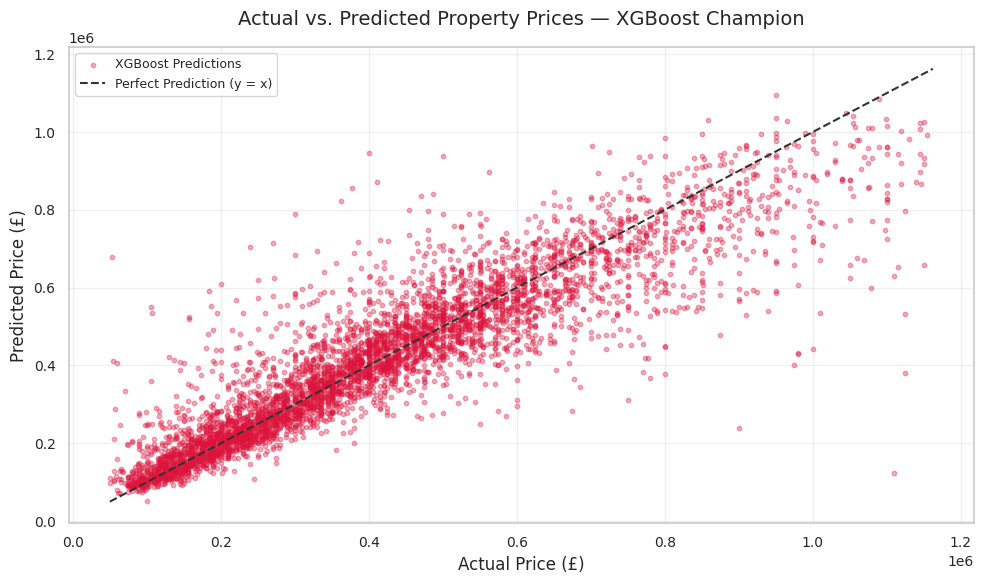

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Final Model Training · Official Metrics · Actual vs. Predicted
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Assemble Final Parameters ──────────────────────────────────────────────
# Merge Optuna-derived parameters with static GPU and reproducibility constants.
final_params_xgb = {
    **study_xgb.best_params,
    'tree_method' : 'hist',
    'device'      : 'cuda',
    'random_state': 42,
    'verbosity'   : 0,
}

# ── 2. Train Final Model ──────────────────────────────────────────────────────
print("Training the optimised XGBoost champion (GPU-accelerated)...\n")

start_time = time.time()
xgb_final = xgb.XGBRegressor(**final_params_xgb)
xgb_final.fit(X_train, y_train, verbose=False)
elapsed = time.time() - start_time
print(f"✅ Champion trained in {elapsed:.2f} seconds.")

# ── 3. Evaluation on Hold-Out Test Set (20%) ──────────────────────────────────
y_pred_final = xgb_final.predict(X_test)

r2_final   = r2_score(y_test, y_pred_final)
mae_final  = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mape_final = mean_absolute_percentage_error(y_test, y_pred_final) * 100

print("\n── Final Results: XGBoost vs. Full Benchmark Panel ──────────────────")
print(f"{'Model':<22} {'R²':>8} {'MAE (£)':>14} {'RMSE (£)':>14}")
print(f"{'─'*22} {'─'*8} {'─'*14} {'─'*14}")
print(f"{'OLS Baseline':<22} {OLS_R2:>8.4f} {OLS_MAE:>14,.2f} {OLS_RMSE:>14,.2f}")
print(f"{'LightGBM Champion':<22} {LGBM_R2:>8.4f} {LGBM_MAE:>14,.2f} {LGBM_RMSE:>14,.2f}")
print(f"{'Random Forest Champion':<22} {RF_R2:>8.4f} {RF_MAE:>14,.2f} {RF_RMSE:>14,.2f}")
print(f"{'XGBoost Champion':<22} {r2_final:>8.4f} {mae_final:>14,.2f} {rmse_final:>14,.2f}")
print(f"\n   XGBoost MAPE : {mape_final:.2f}%")

# ── 4. Actual vs. Predicted Scatter (5,000-point sample, fixed seed) ──────────
rng        = np.random.default_rng(seed=42)
sample_idx = rng.choice(len(y_test), size=min(5_000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    y_test.iloc[sample_idx],
    y_pred_final[sample_idx],
    alpha=0.35, color=ACCENT, s=10,
    label='XGBoost Predictions',
)
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#333333', linestyle='--', linewidth=1.5,
    label='Perfect Prediction (y = x)',
)

ax.set_title(
    'Actual vs. Predicted Property Prices — XGBoost Champion',
    fontsize=14, pad=16
)
ax.set_xlabel('Actual Price (£)',    fontsize=12)
ax.set_ylabel('Predicted Price (£)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Final Conclusions: XGBoost — The Definitive Predictive Champion

Following the rigorous Bayesian optimization process, the **XGBoost** model demonstrated its algorithmic supremacy, emerging as the undisputed predictive champion of the entire study. It fully validates the adoption of non-linear *Machine Learning* techniques for complex real estate valuations.

**1. Excellence in Performance:**
The final model achieved an **R² of 0.8249**, accompanied by the lowest errors across all evaluation metrics: a **MAE of £60,868.46**, an **RMSE of £94,954.19**, and an exceptional **MAPE of 17.67%**. Benefiting from advanced L1/L2 regularization and sequential error correction, XGBoost successfully squeezed and extracted more analytical signal from the spatial and structural data than both Random Forest and LightGBM.

**2. The Final Baseline Comparison:**
Compared to the classic hedonic linear model (OLS), XGBoost secured an improvement of **7.9 percentage points in explained variance (R²)** and reduced the mean absolute prediction error (MAE) by a massive **£18,580.71 per transaction**. Furthermore, it confidently shattered the £100k RMSE barrier, proving vastly superior in handling the extreme price variance and luxury outliers of the UK housing market.

**3. The Computational Advantage:**
Beyond pure accuracy, the GPU-accelerated architecture (`device='cuda'`) trained the final heavily-parameterized champion in just **19.64 seconds** — a stark contrast to the 25.25 minutes required by the CPU-bound Random Forest, highlighting the operational efficiency of modern Gradient Boosting.

**Next Steps (Phase 7 - SHAP):**
With the official "Champion" determined, the purely predictive goal of Objective 1 is complete. The research now transitions to the interpretative phase (Objective 2). The saved XGBoost model will be submitted to the **SHAP** framework (based on cooperative Game Theory) to open the algorithm's "black box". This will allow us to isolate the exact financial impact of the `CURRENT_ENERGY_RATING` variable on price formation, revealing the ultimate, isolated value of the *Green Premium*.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Persist Final Model to Google Drive
# ══════════════════════════════════════════════════════════════════════════════

model_path = MODELS_PATH + 'xgboost_otimizado_campeao.pkl'
joblib.dump(xgb_final, model_path)

print(f"✅ XGBoost champion saved → {model_path}")
print(f"\n   The saved model will be loaded by the SHAP cells below.")
print(f"   Do not clear the runtime before running Phase 7.")

✅ XGBoost champion saved → /content/drive/MyDrive/Tese/Modelos/xgboost_otimizado_campeao.pkl

   The saved model will be loaded by the SHAP cells below.
   Do not clear the runtime before running Phase 7.


###Another Color Option

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded: 547,948 rows
✅ After INVALID_BANDS filter: 514,345 rows
✅ Test set size: 102,869 observations
✅ Feature alignment: 53 features (expected 53)
✅ Predictions generated: 102,869 observations


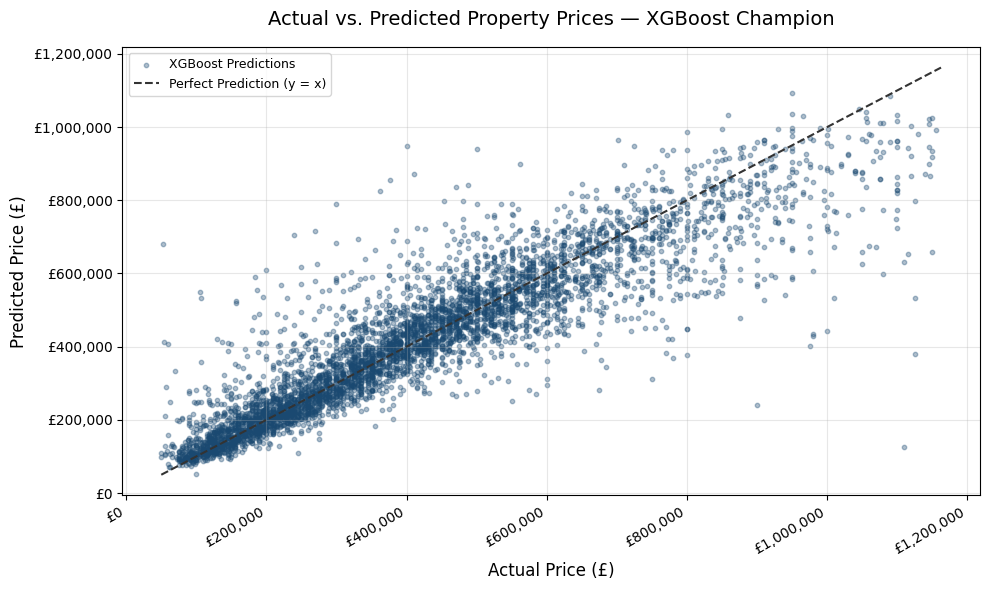

✅ Figure saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STANDALONE CELL — Actual vs. Predicted: XGBoost Champion
# Reconstructs test set from Dataset_Final_Tese.csv using the same
# preprocessing pipeline and train/test split seed as NB06
# ══════════════════════════════════════════════════════════════════════════════

# ── 0. Imports ────────────────────────────────────────────────────────────────
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib, json, re
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

# ── 1. File paths ─────────────────────────────────────────────────────────────
MODEL_PATH    = '/content/drive/MyDrive/Tese/Modelos/xgboost_otimizado_campeao.pkl'
DATA_PATH     = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
FEATURES_PATH = '/content/drive/MyDrive/Tese/Modelos/approved_features_53.json'
FIGURES_PATH  = '/content/drive/MyDrive/Tese/Figures/'

# ── 2. Load dataset and replicate NB06 preprocessing ─────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded: {len(df):,} rows")

# Standard pipeline filter (identical to NB03–NB06)
INVALID_BANDS = ['INVALID!', 'Unknown', '2042']
df = df[~df['CONSTRUCTION_AGE_BAND'].isin(INVALID_BANDS)].copy()
print(f"✅ After INVALID_BANDS filter: {len(df):,} rows")

# EPC ordinal encoding (same as NB06 — stored back under original column name)
EPC_MAP = {'A':7, 'B':6, 'C':5, 'D':4, 'E':3, 'F':2, 'G':1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(EPC_MAP)

# Separate target and features
y = df['Price']
X = df.drop(columns=['Price'])

# One-Hot Encode the same categorical columns as NB06
OHE_COLS = [
    'Property_Type', 'Old_New', 'Tenure_Duration',
    'CONSTRUCTION_AGE_BAND', 'Year_of_Transfer', 'Month_of_Transfer'
]
X = pd.get_dummies(X, columns=OHE_COLS, drop_first=True)

# Clean column names — XGBoost rejects special characters;
# replicate the same sanitisation applied before training
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c).strip('_') for c in X.columns]

# ── 3. Reconstruct the identical test split (same seed as NB06) ───────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"✅ Test set size: {len(X_test):,} observations")

# ── 4. Align X_test to the 53 approved features ───────────────────────────────
with open(FEATURES_PATH) as f:
    approved_features = json.load(f)

# reindex: keeps only approved columns, fills any absent column with 0
X_test = X_test.reindex(columns=approved_features, fill_value=0)
print(f"✅ Feature alignment: {X_test.shape[1]} features (expected 53)")

# ── 5. Load model and generate predictions ────────────────────────────────────
model        = joblib.load(MODEL_PATH)
y_pred_final = model.predict(X_test)
print(f"✅ Predictions generated: {len(y_pred_final):,} observations")

# ── 6. Actual vs. Predicted scatter (5,000-point sample, fixed seed) ──────────
plt.rcParams.update({
    'axes.titlesize'  : 14,
    'axes.titlepad'   : 16,
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'legend.fontsize' :  9,
})

rng        = np.random.default_rng(seed=42)
sample_idx = rng.choice(len(y_test), size=min(5_000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    y_test.iloc[sample_idx],
    y_pred_final[sample_idx],
    alpha = 0.35,
    color = '#1a4971',
    s     = 10,
    label = 'XGBoost Predictions',
)
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color     = '#333333',
    linestyle = '--',
    linewidth = 1.5,
    label     = 'Perfect Prediction (y = x)',
)

# £ currency formatting on both axes
gbp_fmt = mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
ax.xaxis.set_major_formatter(gbp_fmt)
ax.yaxis.set_major_formatter(gbp_fmt)
plt.xticks(rotation=30, ha='right')

ax.set_title('Actual vs. Predicted Property Prices — XGBoost Champion', pad=16)
ax.set_xlabel('Actual Price (£)')
ax.set_ylabel('Predicted Price (£)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH + 'figure_actual_vs_predicted_xgboost.png',
    dpi=300, bbox_inches='tight',
)
plt.show()
print("✅ Figure saved.")